# 04 - Modele SVM RBF

## 1. Objectif et protocole

Mesurer la valeur ajoutee d'un noyau RBF sur des donnees correctement scalees.

Protocole publie dans ce notebook:
- `simple CV` stratifiee pour comparer les variantes non tunees.
- `GridSearchCV` pour cartographier l'espace hyperparametrique de maniere exploratoire.
- `nested CV` pour la performance finale confirmatoire.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.evaluation import (
    calculer_brier_score_multiclasse,
    calculer_statistiques_confiance,
    calculer_top_k_accuracies,
    matrice_confusion_normalisee,
    classes_difficiles,
    top_confusions,
    verifier_overfit_petit_echantillon,
)
from src.notebook_support import (
    calculer_importance_permutation_exploratoire,
    calculer_metriques_classes_depuis_predictions,
    charger_ou_generer_predictions_variante,
    construire_tableau_gaps,
    construire_resume_confusions_variantes,
    construire_tableau_plis_externes,
    construire_tableau_variantes,
    creer_notebook_context,
    evaluer_variantes_untuned,
    executer_tuning_confirmatoire,
    executer_verifications_validite,
)
from src.plots import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_histogramme_confiance,
    tracer_hyperparametre_vs_performance,
    tracer_matrice_confusion,
    tracer_metrique_par_classe,
    tracer_reliability_diagram,
    tracer_top_confusions,
)


In [2]:
MODEL_NAME = "svm"
ctx = creer_notebook_context(MODEL_NAME)
spec = ctx.spec
definition = ctx.definition
X, y, label_encoder = ctx.X, ctx.y, ctx.label_encoder

protocole = pd.DataFrame(
    [
        ("Modele", definition["nom_affiche"]),
        ("Famille", definition["famille"]),
        ("Metrique principale", "macro-F1"),
        ("Exploration", "simple CV + grid search"),
        ("Confirmation", "nested CV"),
    ],
    columns=["axe", "choix"],
)
display(protocole)


,axe,choix
0,Modele,SVM RBF
1,Famille,noyau
2,Metrique principale,macro-F1
3,Exploration,simple CV + grid search
4,Confirmation,nested CV


## 2. Signal attendu et design experimental

**Design experimental**
- Le SVM RBF reste sensible a l'echelle; toutes les variantes pretraitees passent par StandardScaler.
- La selection finale conserve probability=True pour que le cout temporel publie inclue l'estimation probabiliste.
- Ces probabilites restent secondaires dans l'analyse : elles proviennent d'une calibration interne et ne servent pas de base au classement final, qui repose sur la `macro-F1` en `nested CV`.
- Le diagnostic principal du tuning reste la surface C x gamma, lue separement par etat PCA.

**Signal attendu**
- Le scaling est un pre-requis; sans lui, le SVM doit rester nettement moins performant.
- Le noyau RBF n'est justifie scientifiquement que si le gain confirme compense son cout en temps.

**Refutation pratique**
- Si ces motifs n'apparaissent pas, ou s'inversent dans la `nested CV`, l'hypothese du modele n'est pas consideree comme confirmee.


In [3]:
design_table = pd.DataFrame(
    {
        "variante": [variant.name for variant in spec.untuned_variants],
        "type": [variant.kind for variant in spec.untuned_variants],
        "parametres_forces": [variant.params or {} for variant in spec.untuned_variants],
    }
)
display(design_table)


,variante,type,parametres_forces
0,default,simple,{}
1,scaled_only,pipeline_no_pca,{}
2,scaled_pca,pipeline_with_pca,{}


## 3. Resultats exploratoires non tunes

Cette section sert a mesurer les variantes sans selection d'hyperparametres finale.
Les gaps train/validation restent uniquement descriptifs a ce stade.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,scaled_only,simple_cv,improved_untuned,0.9838,0.0081,0.9821,0.0094,0.9972,0.9972,0.0134,0.0151,3.5566,cv_n_jobs=1
1,scaled_pca,simple_cv,improved_untuned,0.9838,0.0081,0.9821,0.0094,0.9972,0.9972,0.0134,0.0151,4.0328,cv_n_jobs=1
2,default,simple_cv,baseline,0.9020,0.0206,0.8915,0.0251,0.9793,0.9791,0.0773,0.0876,3.2311,cv_n_jobs=1


,variante,generalization_gap_accuracy,generalization_gap_f1_macro
0,default,0.0773,0.0876
1,scaled_only,0.0134,0.0151
2,scaled_pca,0.0134,0.0151


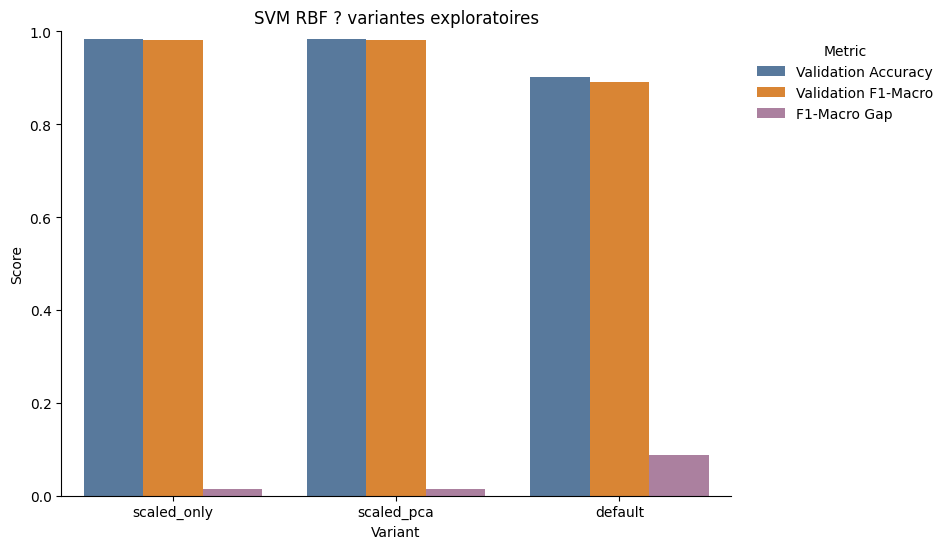

In [4]:
untuned_results = evaluer_variantes_untuned(ctx)
untuned_table = construire_tableau_variantes(untuned_results, None)
gap_table = construire_tableau_gaps(untuned_results)

display(untuned_table.round(4))
display(gap_table.round(4))

tracer_comparaison_variantes(
    untuned_table[[
        "variante",
        "val_accuracy_mean",
        "val_f1_macro_mean",
        "generalization_gap_f1_macro",
    ]],
    ["val_accuracy_mean", "val_f1_macro_mean", "generalization_gap_f1_macro"],
    titre=f"{definition['nom_affiche']} ? variantes exploratoires",
)
plt.show()


## 4. Resultat confirmatoire tuned

Les cartes du `GridSearchCV` restent exploratoires. La seule performance finale a commenter
comme resultat confirmatoire est la ligne `tuned` obtenue en `nested CV`.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,tuned,nested_cv,tuned,0.9869,0.0092,0.9853,0.0109,NaN,NaN,NaN,NaN,109.9879,cv_n_jobs=1
1,scaled_only,simple_cv,improved_untuned,0.9838,0.0081,0.9821,0.0094,0.9972,0.9972,0.0134,0.0151,3.5566,cv_n_jobs=1
2,scaled_pca,simple_cv,improved_untuned,0.9838,0.0081,0.9821,0.0094,0.9972,0.9972,0.0134,0.0151,4.0328,cv_n_jobs=1
3,default,simple_cv,baseline,0.9020,0.0206,0.8915,0.0251,0.9793,0.9791,0.0773,0.0876,3.2311,cv_n_jobs=1


,fold,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,fit_time,score_time,best_score_inner
0,1,1.0,1.0,0.9798,0.9785,17.2685,0.0282,0.9800
1,2,1.0,1.0,0.9949,0.9946,18.8130,0.0278,0.9818
2,3,1.0,1.0,0.9747,0.9697,22.8722,0.0450,0.9814
3,4,1.0,1.0,0.9899,0.9892,24.2817,0.0376,0.9840
4,5,1.0,1.0,0.9949,0.9946,25.4630,0.0390,0.9752


,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_fit_time,param_modele__C,param_modele__gamma,param_pca
6,1,0.9872,0.0024,0.4539,10.0,scale,passthrough
7,1,0.9872,0.0024,0.4932,10.0,scale,"PCA(n_components=0.99, random_state=42)"
2,3,0.9807,0.0032,0.4690,1.0,0.01,passthrough
8,4,0.9797,0.0045,0.4766,10.0,0.01,passthrough
9,5,0.9793,0.0032,0.4833,10.0,0.01,"PCA(n_components=0.99, random_state=42)"
3,6,0.9792,0.0032,0.5540,1.0,0.01,"PCA(n_components=0.99, random_state=42)"
0,7,0.9775,0.0051,0.5159,1.0,scale,passthrough
1,8,0.9760,0.0032,0.5222,1.0,scale,"PCA(n_components=0.99, random_state=42)"
11,9,0.5601,0.0250,0.4639,10.0,0.1,"PCA(n_components=0.99, random_state=42)"
10,10,0.5284,0.0405,0.4474,10.0,0.1,passthrough


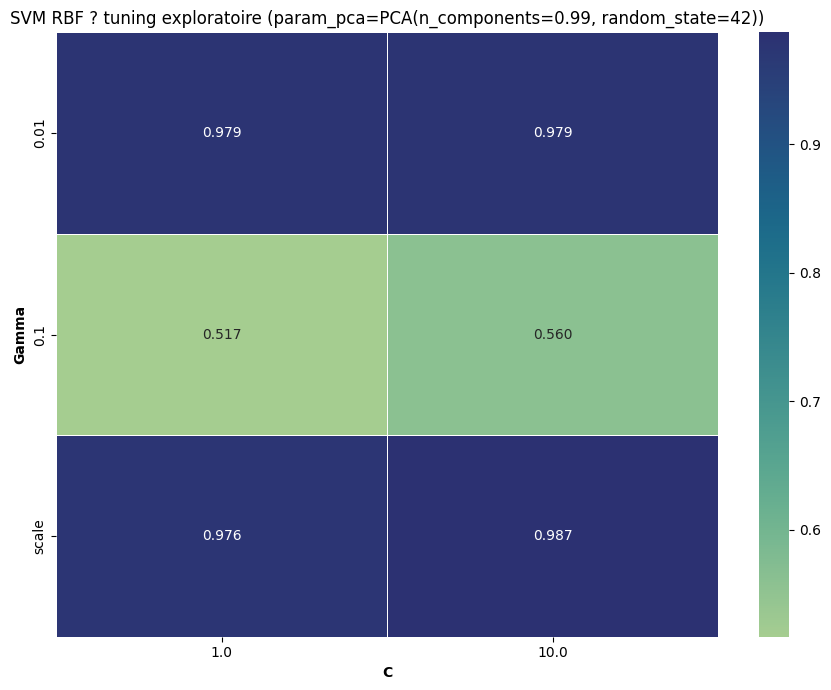

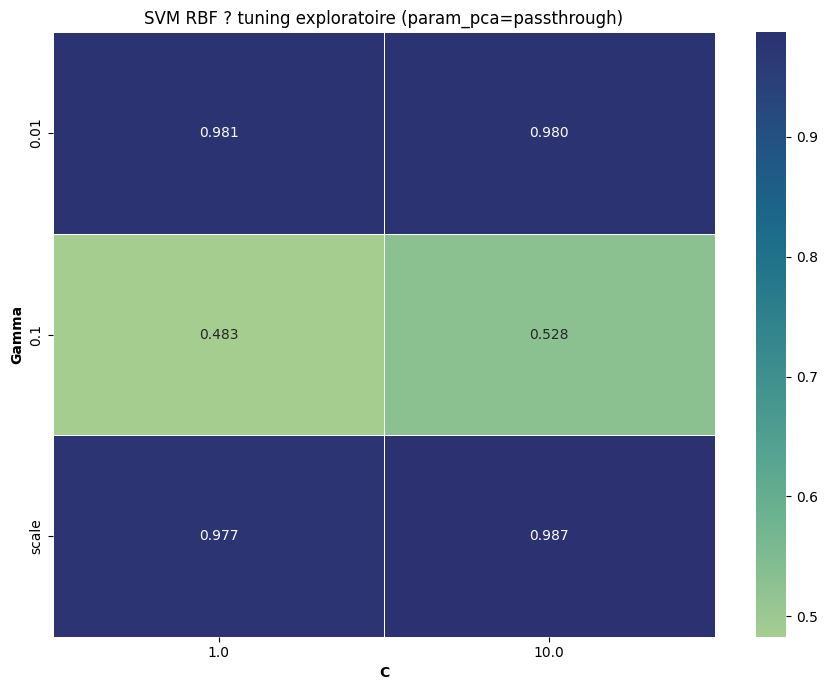

In [5]:
tuning = executer_tuning_confirmatoire(ctx)
summary_table = construire_tableau_variantes(untuned_results, tuning["metrics"])
fold_table = construire_tableau_plis_externes(tuning["nested"])
grid_results = tuning["grid_results"].copy()
shortlist = grid_results.sort_values("rank_test_f1_macro").head(10)

display(summary_table.round(4))
display(fold_table.round(4))

colonnes_shortlist = [
    colonne
    for colonne in [
        "rank_test_f1_macro",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_fit_time",
    ] + [col for col in shortlist.columns if col.startswith("param_")]
    if colonne in shortlist.columns
]
display(shortlist[colonnes_shortlist].round(4))

if spec.tuning_heatmap_axes is not None:
    axe_x, axe_y = spec.tuning_heatmap_axes
    colonne_facette = spec.tuning_facet_column
    if colonne_facette and colonne_facette in grid_results.columns:
        for valeur_facette, sous_tableau in grid_results.groupby(colonne_facette):
            if sous_tableau[[axe_x, axe_y]].drop_duplicates().shape[0] != len(sous_tableau):
                continue
            tracer_heatmap_tuning(
                sous_tableau,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire ({colonne_facette}={valeur_facette})",
            )
            plt.show()
    elif axe_x in grid_results.columns and axe_y in grid_results.columns:
        if grid_results[[axe_x, axe_y]].drop_duplicates().shape[0] == len(grid_results):
            tracer_heatmap_tuning(
                grid_results,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire",
            )
            plt.show()
        else:
            tracer_hyperparametre_vs_performance(
                grid_results,
                x=axe_x,
                y="mean_test_f1_macro",
                hue=axe_y,
                titre=f"{definition['nom_affiche']} ? lecture exploratoire du tuning",
            )
            plt.show()


## 5. Verifications de validite scientifique

Cette section impose le meme contrat minimal dans tous les notebooks:
baseline dummy, test de bruit aleatoire et rappel protocolaire.


In [6]:
validite = executer_verifications_validite(ctx)
display(Markdown(f"**Note protocolaire.** {validite['note']}"))
display(validite["dummy"].round(4))
display(validite["random_noise"].round(4))

if MODEL_NAME == "mlp":
    mini_overfit = pd.DataFrame([verifier_overfit_petit_echantillon()])
    display(Markdown("**Sanity check additionnel MLP.** Ce test verifie qu'un reseau dense peut sur-apprendre un micro-echantillon synthetique."))
    display(mini_overfit.round(4))


**Note protocolaire.** Les variantes non tunees restent exploratoires; les figures refittees sur tout le dataset aussi. Les predictions OOF de la variante tuned sont des diagnostics descriptifs confirmatoires, mais seul le score tuned en nested CV sert au classement final inter-modeles.

,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,reference
0,0.0101,0.0,0.0002,0.0,0.0101,0.0002,0.0022,0.0052,0.0649,5,dummy,most_frequent,DummyClassifier


,val_accuracy_mean,val_f1_macro_mean,chance_level,near_chance,reference
0,0.0071,0.0055,0.0101,True,Bruit aleatoire


## 6. Diagnostics du modele

Les tableaux et graphiques issus des predictions `OOF` de la `nested CV` sont confirmatoires.
Les diagnostics issus d'un refit global ou du `grid search` complet sont explicitement exploratoires.

Pour le SVM, les probabilites OOF obtenues avec `probability=True` restent des diagnostics secondaires de calibration : elles sont utiles a inspecter, mais ne remplacent ni le `macro-F1` ni la `nested CV` pour classer le modele.


,classe,precision,recall,f1,support,fpr,fnr,specificite
0,Lithocarpus_Edulis,1.0,0.8,0.8889,10,0.000,0.2,1.000
1,Quercus_Pontica,1.0,0.8,0.8889,10,0.000,0.2,1.000
2,Populus_Adenopoda,1.0,0.9,0.9474,10,0.000,0.1,1.000
3,Eucalyptus_Neglecta,1.0,0.9,0.9474,10,0.000,0.1,1.000
4,Prunus_X_Shmittii,1.0,0.9,0.9474,10,0.000,0.1,1.000
5,Quercus_Phillyraeoides,1.0,0.9,0.9474,10,0.000,0.1,1.000
6,Quercus_Palustris,0.9,0.9,0.9000,10,0.001,0.1,0.999
7,Quercus_Castaneifolia,1.0,0.9,0.9474,10,0.000,0.1,1.000
8,Quercus_Pubescens,1.0,0.9,0.9474,10,0.000,0.1,1.000
9,Quercus_Suber,1.0,0.9,0.9474,10,0.000,0.1,1.000


,classe_vraie,classe_predite,nombre_erreurs
0,Lithocarpus_Edulis,Lithocarpus_Cleistocarpus,2
1,Eucalyptus_Neglecta,Eucalyptus_Glaucescens,1
2,Populus_Adenopoda,Quercus_Ilex,1
3,Prunus_X_Shmittii,Morus_Nigra,1
4,Quercus_Castaneifolia,Quercus_Kewensis,1
5,Quercus_Palustris,Quercus_Shumardii,1
6,Quercus_Phillyraeoides,Castanea_Sativa,1
7,Quercus_Pontica,Quercus_Agrifolia,1
8,Quercus_Pontica,Quercus_Greggii,1
9,Quercus_Pubescens,Quercus_Greggii,1


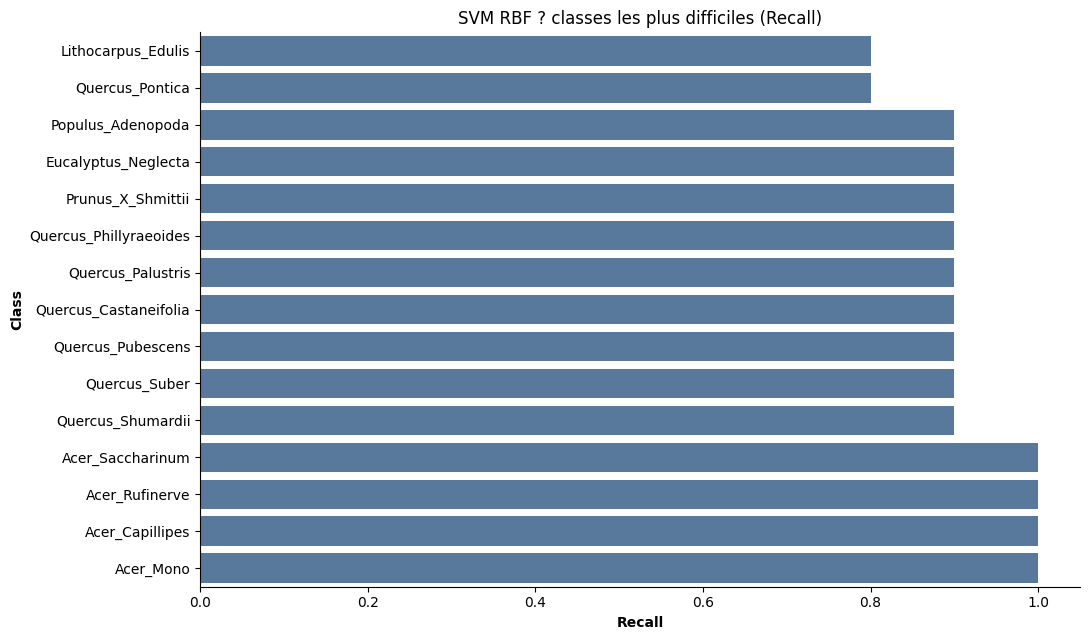

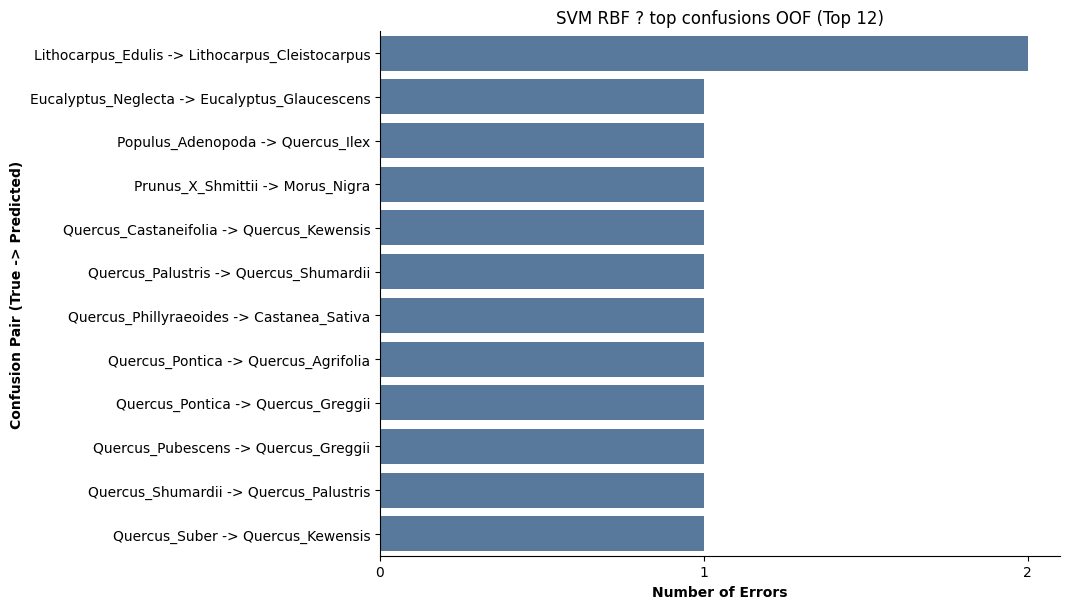

_Pour le SVM, `predict_proba` repose sur une calibration interne (`probability=True`) ; ces indicateurs probabilistes restent secondaires et n'entrent pas dans le classement final, qui repose sur la `macro-F1` de la nested CV._

,top_1_accuracy,top_5_accuracy,confiance_moyenne,confiance_erreurs,brier_multiclasse
0,0.9798,0.999,0.0989,0.0585,0.8241


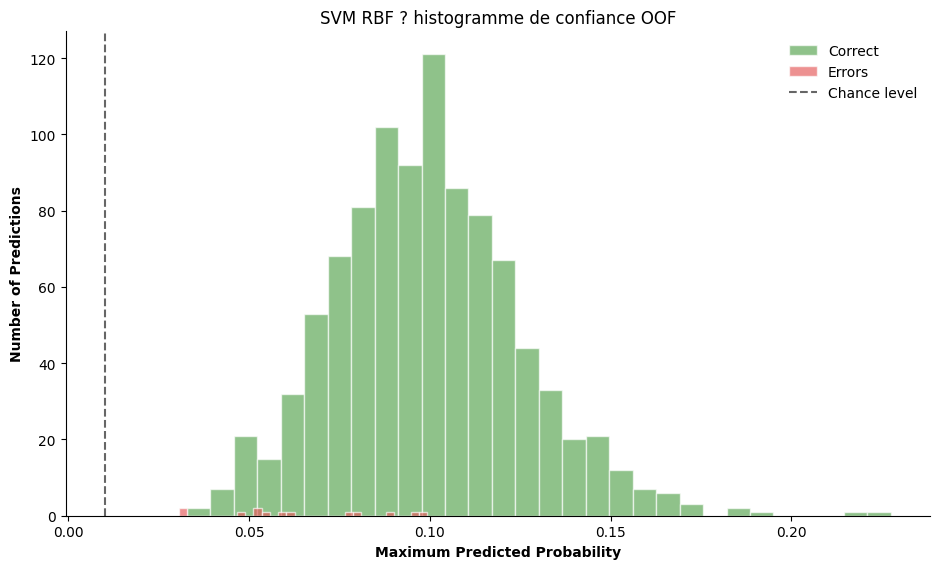

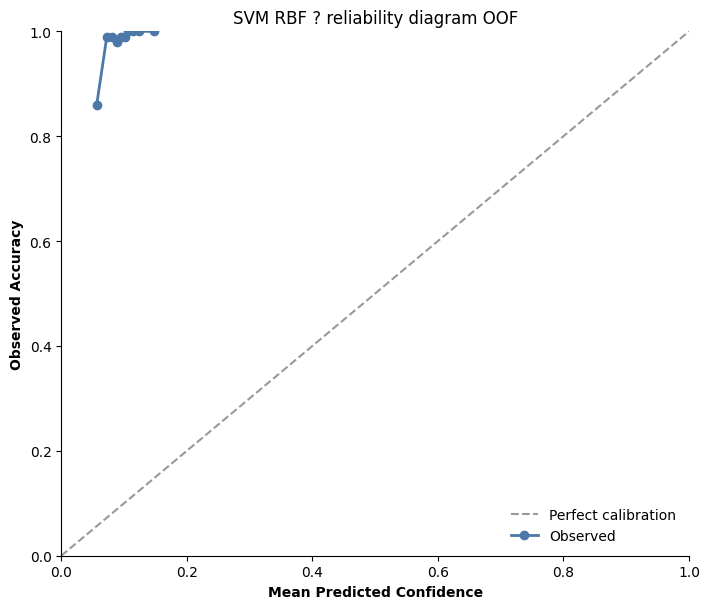

In [7]:
predictions_tuned = tuning["nested"]["oof_predictions"]
classes_table = calculer_metriques_classes_depuis_predictions(predictions_tuned, label_encoder)
difficult_classes = classes_difficiles(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
    metrique="recall",
)
confusions_table = top_confusions(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)

display(difficult_classes.round(4))
display(confusions_table.round(4))

tracer_metrique_par_classe(
    classes_table,
    metrique="recall",
    top_n=15,
    ordre="asc",
    titre=f"{definition['nom_affiche']} ? classes les plus difficiles",
)
plt.show()

if not confusions_table.empty:
    tracer_top_confusions(
        confusions_table,
        top_n=min(15, len(confusions_table)),
        titre=f"{definition['nom_affiche']} ? top confusions OOF",
    )
    plt.show()

probabilites_tuned = tuning["nested"].get("oof_probabilities")
if spec.supports_probabilities and probabilites_tuned is not None:
    topk = calculer_top_k_accuracies(probabilites_tuned)
    confiance = calculer_statistiques_confiance(probabilites_tuned)
    brier = calculer_brier_score_multiclasse(probabilites_tuned)
    tableau_probabilites = pd.DataFrame(
        [
            {
                "top_1_accuracy": topk["top_1_accuracy"],
                "top_5_accuracy": topk["top_5_accuracy"],
                "confiance_moyenne": confiance["confiance_moyenne"],
                "confiance_erreurs": confiance["confiance_erreurs"],
                "brier_multiclasse": brier,
            }
        ]
    )
    display(Markdown("_Pour le SVM, `predict_proba` repose sur une calibration interne (`probability=True`) ; ces indicateurs probabilistes restent secondaires et n'entrent pas dans le classement final, qui repose sur la `macro-F1` de la nested CV._"))
    display(tableau_probabilites.round(4))
    tracer_histogramme_confiance(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? histogramme de confiance OOF",
    )
    plt.show()
    tracer_reliability_diagram(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? reliability diagram OOF",
    )
    plt.show()
else:
    display(Markdown("_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._"))


### Matrices de confusion par variante

Les matrices ci-dessous enrichissent la lecture des erreurs pour chaque variante du modele.
- pour `tuned`, les predictions proviennent des artefacts `OOF` de la `nested CV` ;
- pour les variantes non tunees, les predictions sont reconstruites en `simple CV` avec le protocole partage.

Cette comparaison reste descriptive : elle permet d'observer la structure des erreurs sans transformer
les variantes exploratoires en resultats confirmatoires.


,variante,evaluation_stage,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,confusion_dominante,nombre_erreurs_dominantes
0,default,baseline,0.8915,0.9020,0.0876,Alnus_Cordata -> Tilia_Oliveri,2
1,scaled_only,improved_untuned,0.9821,0.9838,0.0151,Lithocarpus_Edulis -> Lithocarpus_Cleistocarpus,2
2,scaled_pca,improved_untuned,0.9821,0.9838,0.0151,Lithocarpus_Edulis -> Lithocarpus_Cleistocarpus,2
3,tuned,tuned,0.9853,0.9869,NaN,Lithocarpus_Edulis -> Lithocarpus_Cleistocarpus,2


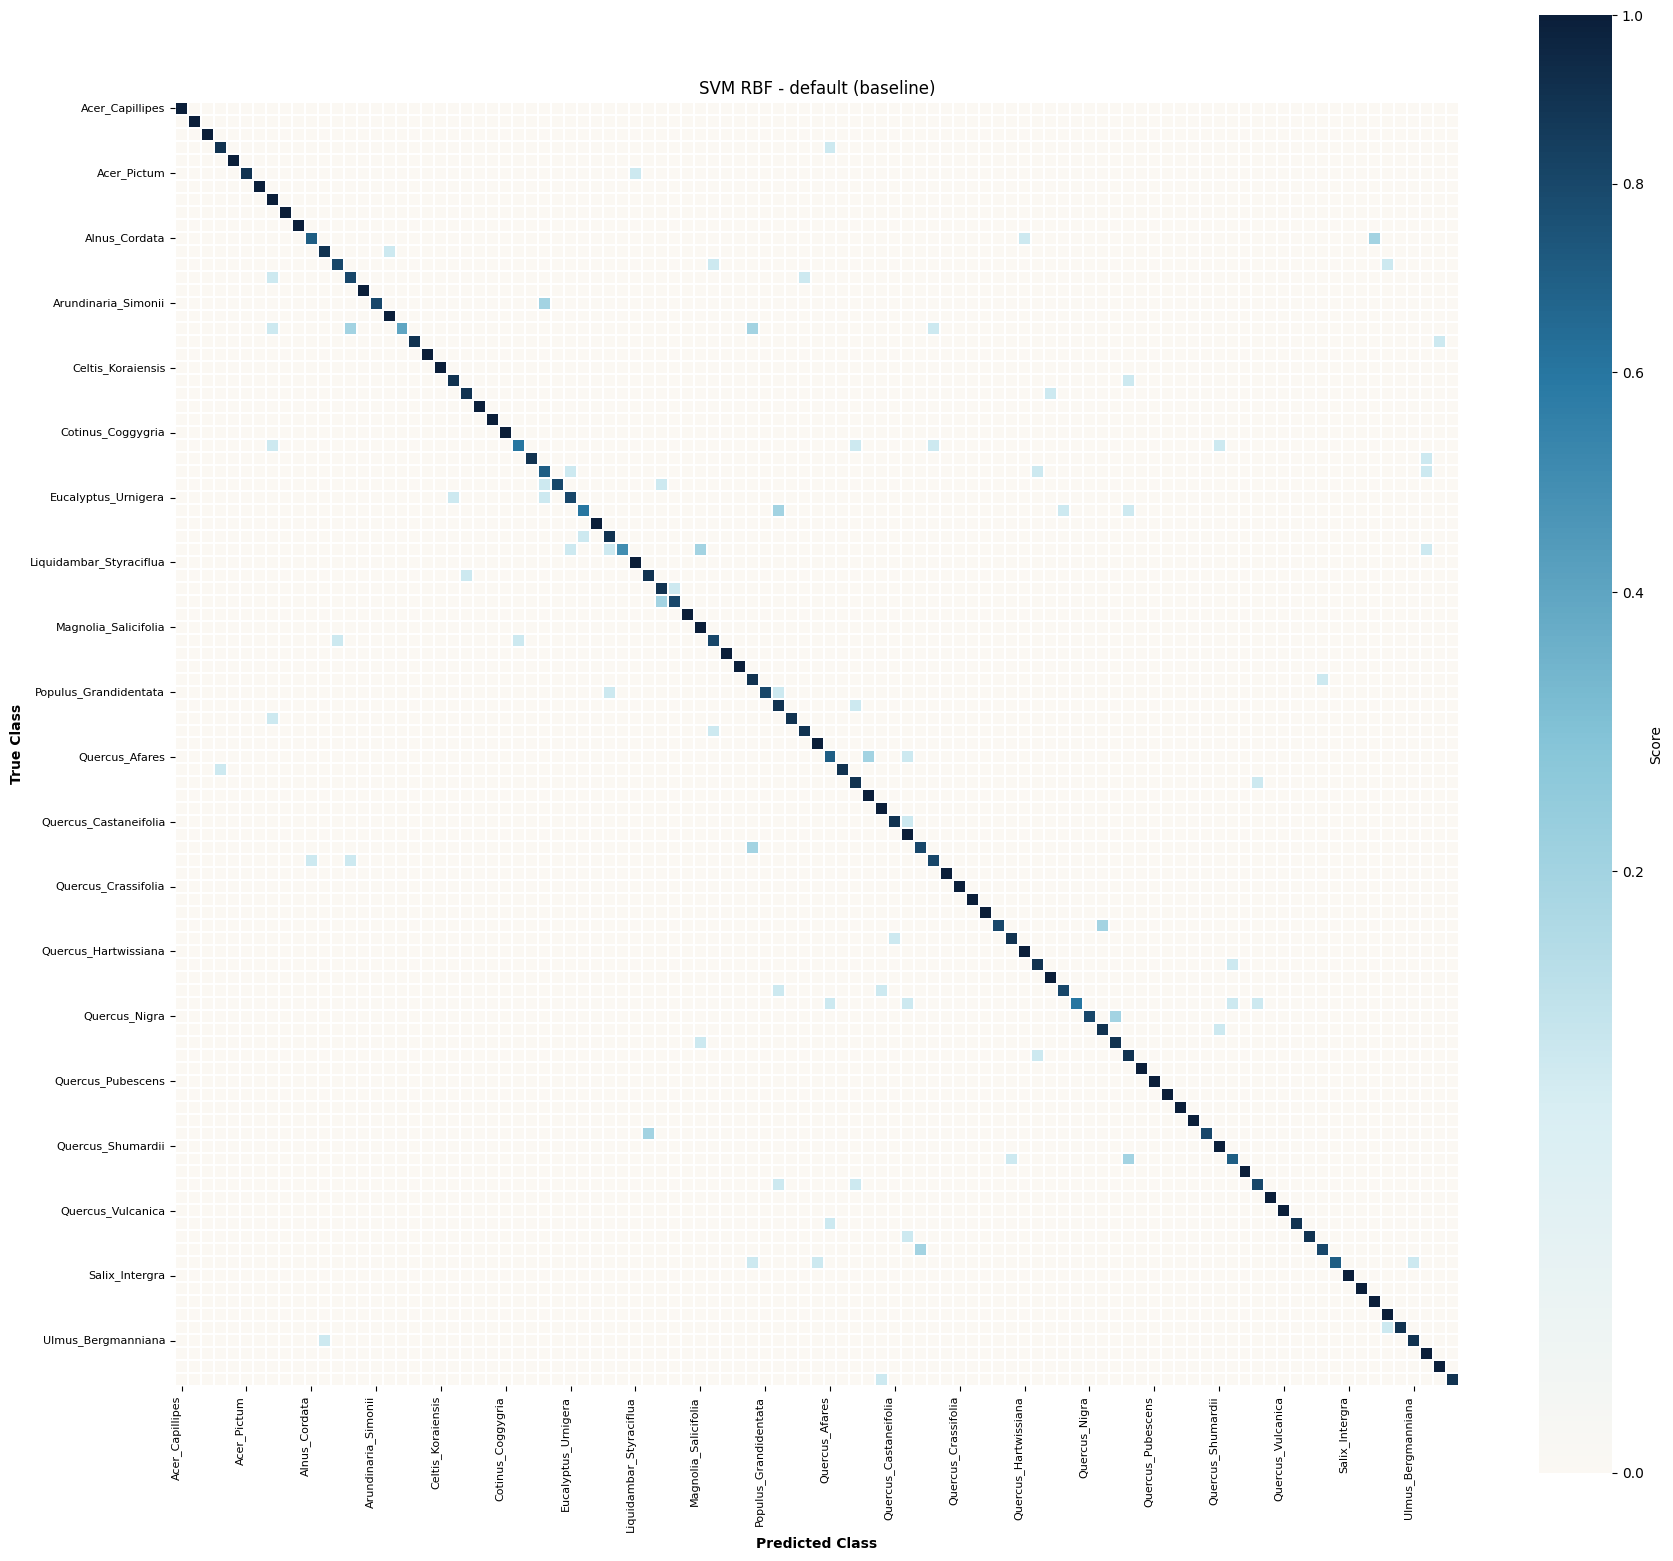

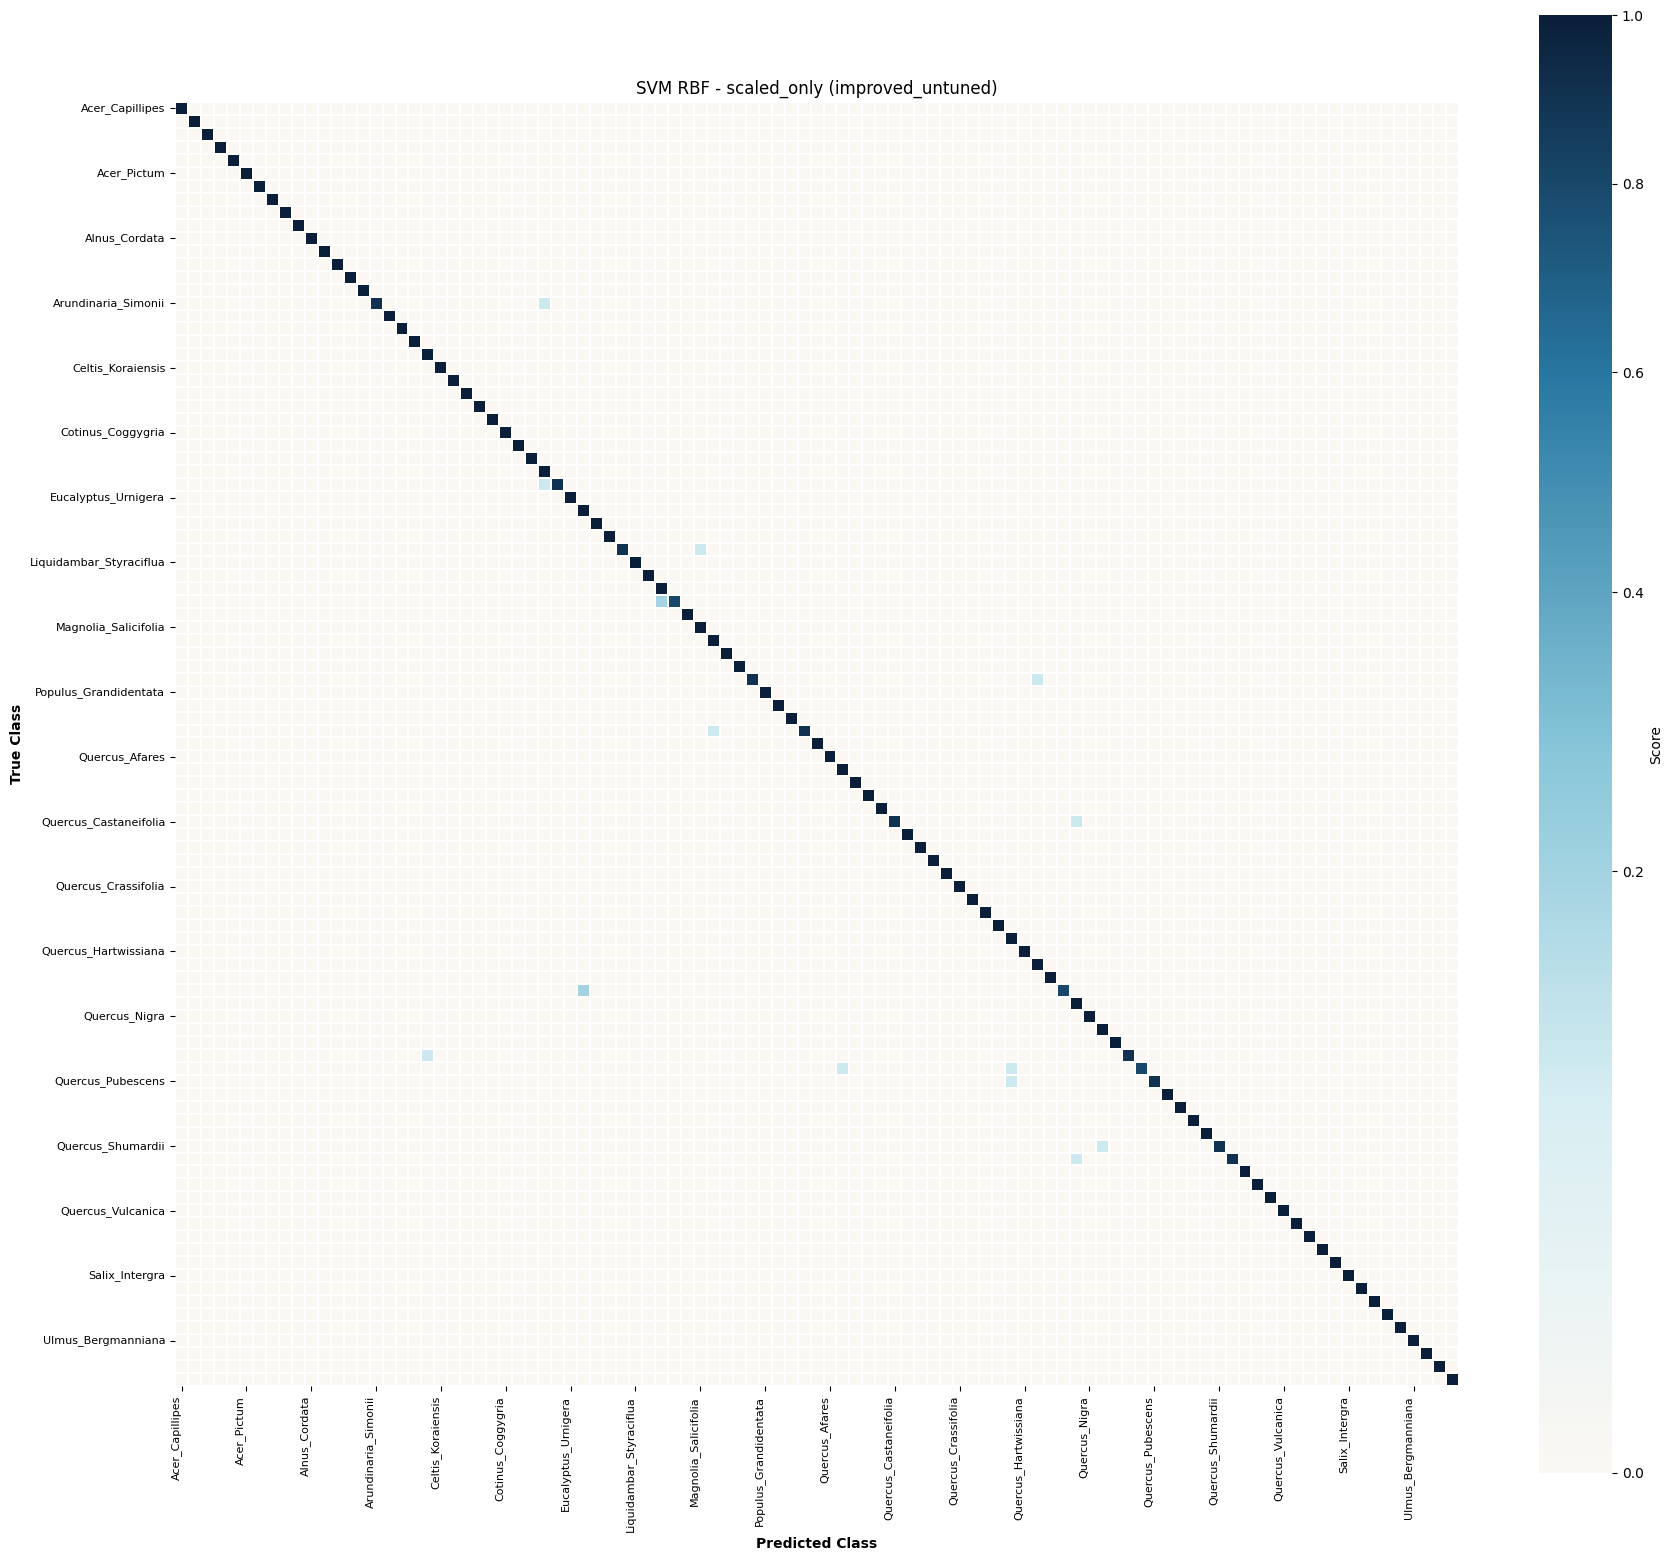

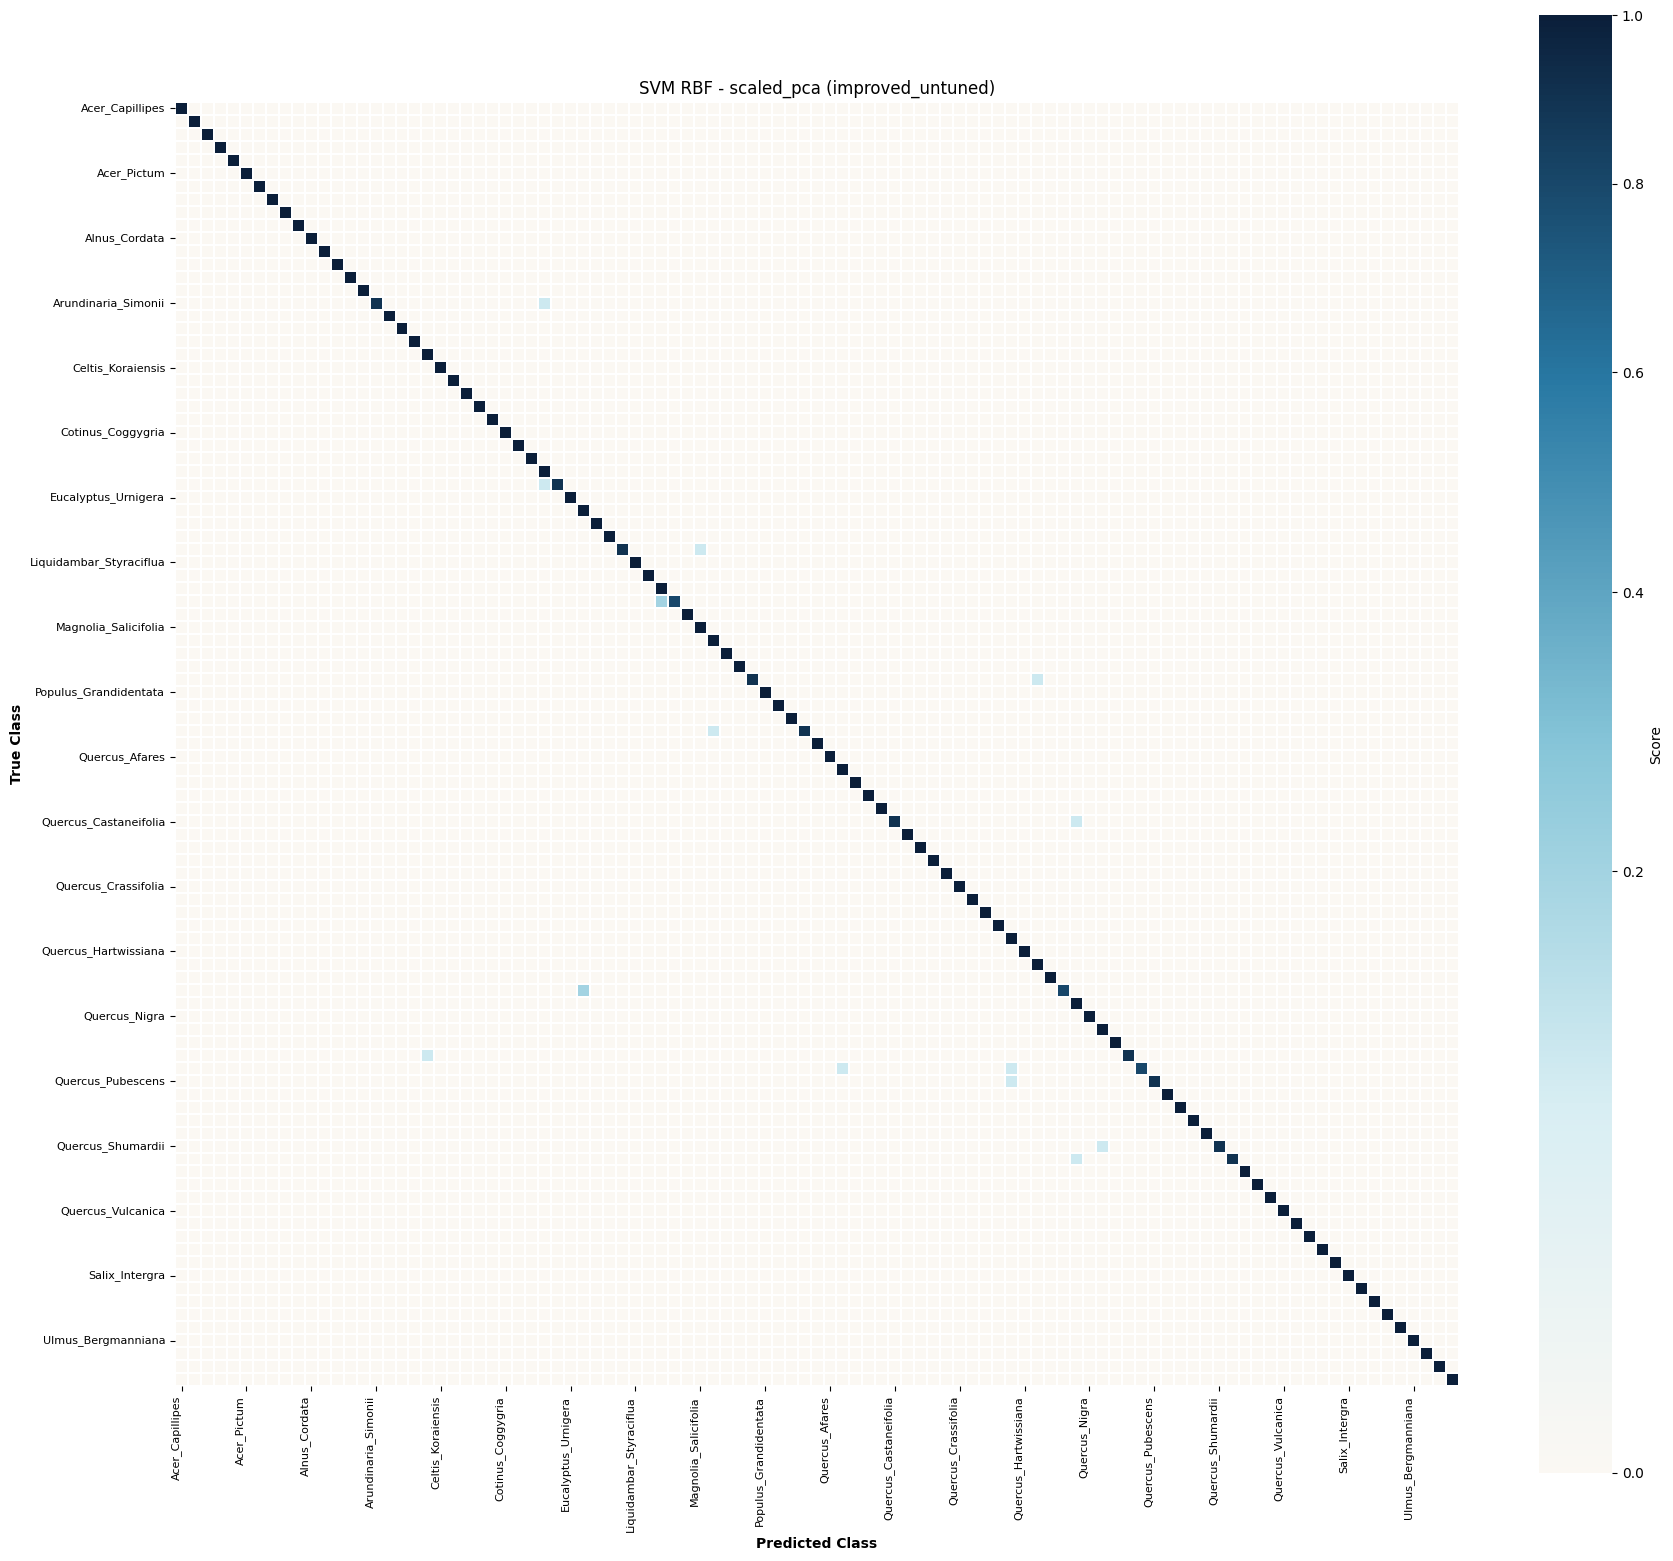

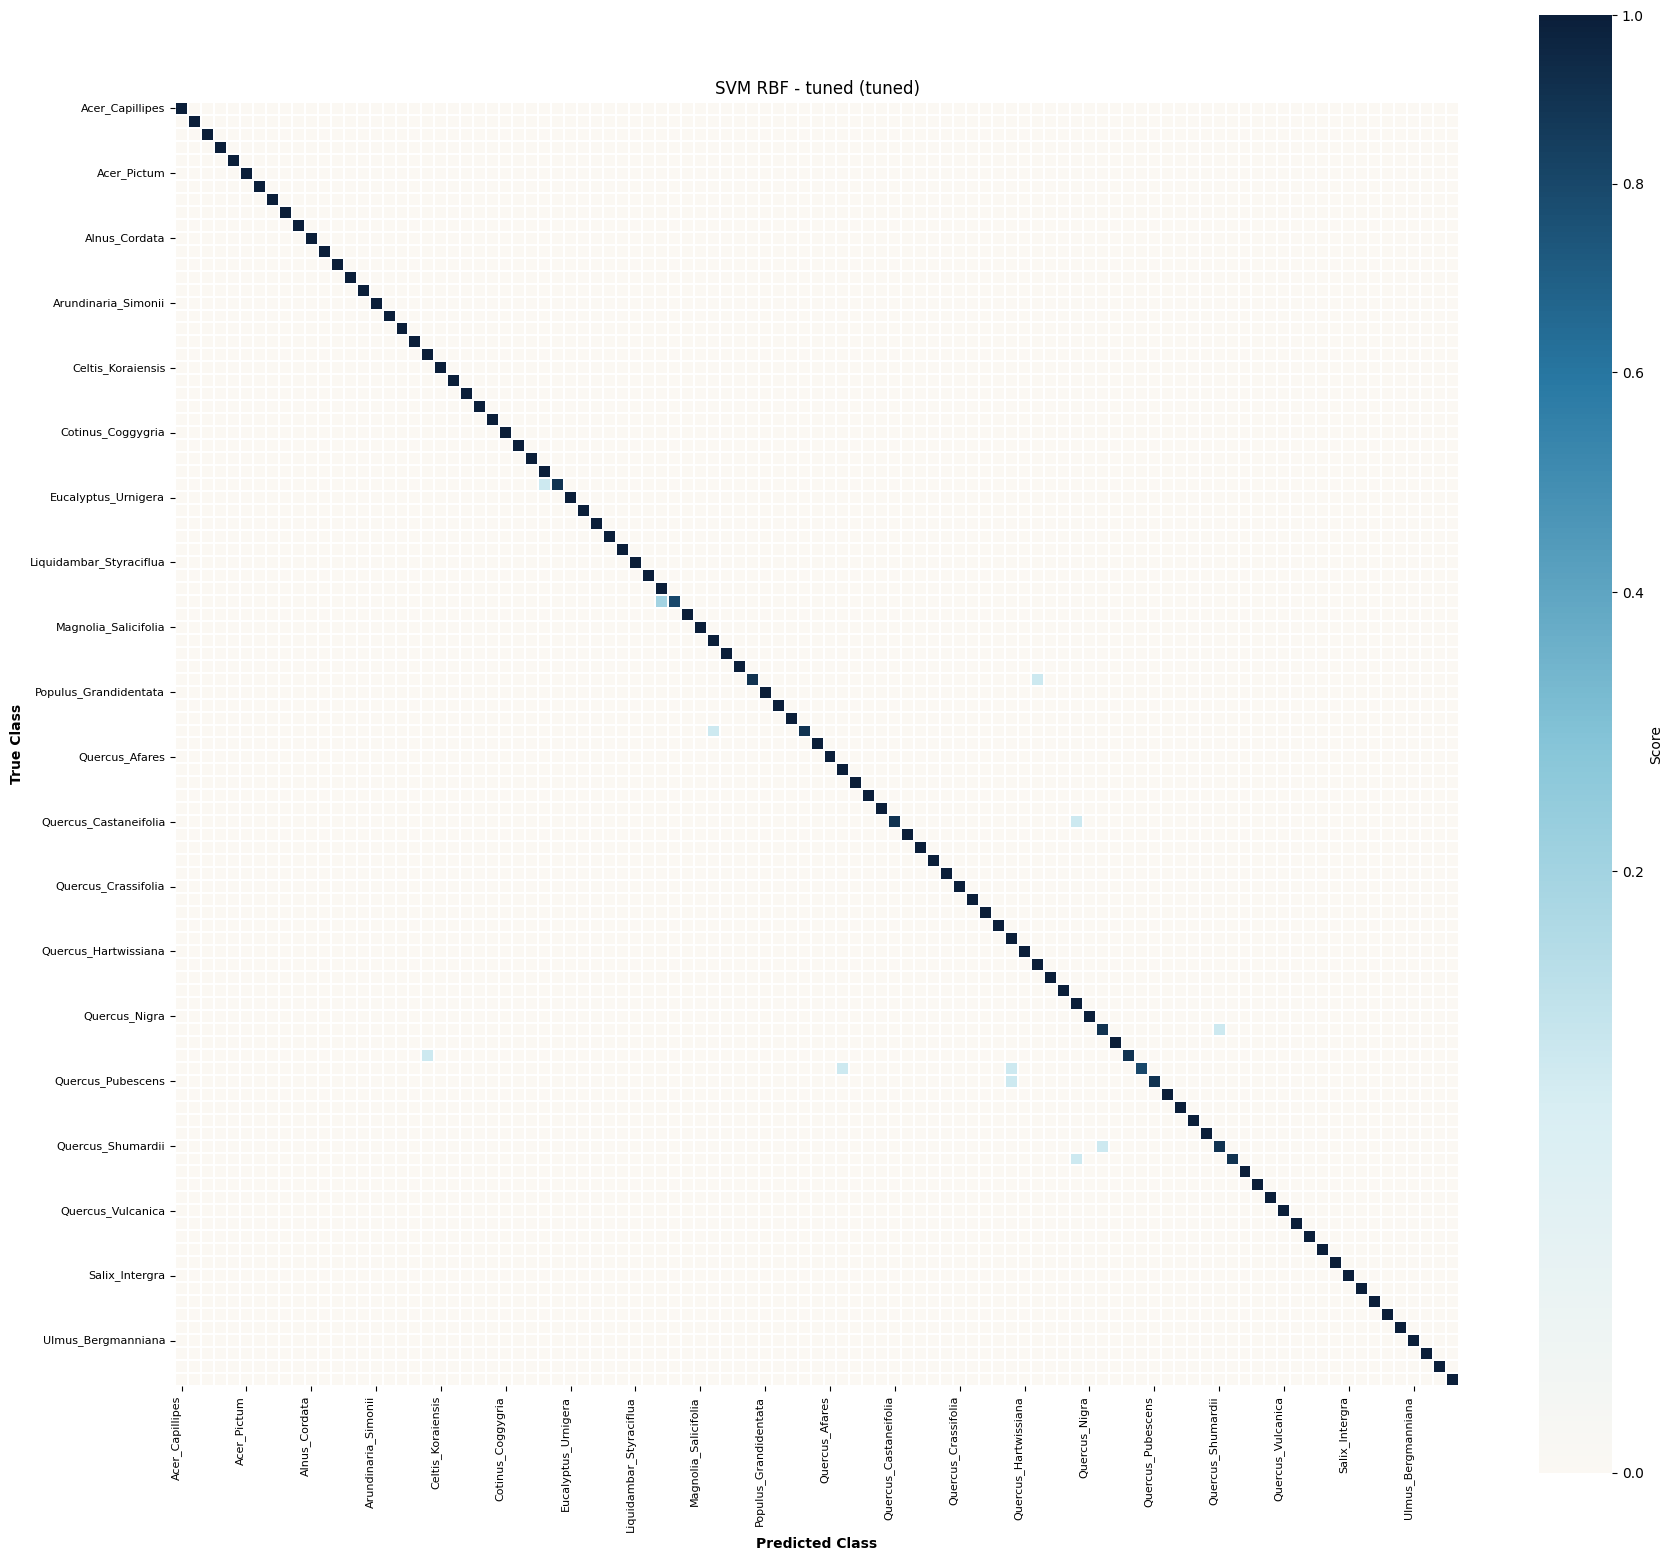

In [8]:
resume_confusions = construire_resume_confusions_variantes(
    MODEL_NAME,
    summary_table,
    X,
    y,
    label_encoder,
)
display(
    resume_confusions[[
        "variante",
        "evaluation_stage",
        "val_f1_macro_mean",
        "val_accuracy_mean",
        "generalization_gap_f1_macro",
        "confusion_dominante",
        "nombre_erreurs_dominantes",
    ]].round(4)
)

ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    resume_confusions
    .assign(
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["_ordre", "variante"])
    .reset_index(drop=True)
)

for ligne in catalogue_variantes.to_dict("records"):
    variante = str(ligne["variante"])
    predictions_variante = charger_ou_generer_predictions_variante(
        MODEL_NAME,
        variante,
        X,
        y,
        label_encoder=label_encoder,
    )
    matrice = matrice_confusion_normalisee(
        predictions_variante["y_true"].to_numpy(),
        predictions_variante["y_pred"].to_numpy(),
        label_encoder=label_encoder,
    )
    tracer_matrice_confusion(
        matrice,
        titre=f"{definition['nom_affiche']} - {variante} ({ligne['evaluation_stage']})",
        annot=False,
        intervalle_ticks=5,
    )
    plt.show()


## 7. Interpretation

Le texte ci-dessous reste automatiquement borne par les chiffres obtenus dans ce notebook.
Il ne doit pas servir a sur-interpreter des signaux purement exploratoires.


In [9]:
best_untuned = untuned_table.sort_values("val_f1_macro_mean", ascending=False).iloc[0]
tuned_row = summary_table.loc[summary_table["variante"] == "tuned"].iloc[0]
default_row = untuned_table.loc[untuned_table["variante"] == "default"].iloc[0]
lignes = [
    f"- Meilleure variante non tunee: `{best_untuned['variante']}` avec F1-macro = `{best_untuned['val_f1_macro_mean']:.4f}`.",
    f"- Estimation confirmatoire `tuned` en nested CV: F1-macro = `{tuned_row['val_f1_macro_mean']:.4f}` et accuracy = `{tuned_row['val_accuracy_mean']:.4f}`.",
]

if "scaled_only" in untuned_table["variante"].values:
    scaled_row = untuned_table.loc[untuned_table["variante"] == "scaled_only"].iloc[0]
    delta_scaling = scaled_row["val_f1_macro_mean"] - default_row["val_f1_macro_mean"]
    lignes.append(
        f"- Effet du scaling sur l'exploration: delta F1-macro = `{delta_scaling:+.4f}` entre `default` et `scaled_only`."
    )

delta_tuning = tuned_row["val_f1_macro_mean"] - best_untuned["val_f1_macro_mean"]
if abs(delta_tuning) < 0.005:
    lignes.append(
        "- Le tuning ne change pas materiellement la lecture scientifique par rapport a la meilleure variante exploratoire."
    )
elif delta_tuning > 0:
    lignes.append(
        f"- Le tuning confirme un gain de `{delta_tuning:+.4f}` en F1-macro par rapport a la meilleure variante exploratoire."
    )
else:
    lignes.append(
        f"- La nested CV donne une estimation plus conservative que l'exploration simple CV (delta F1-macro = `{delta_tuning:+.4f}`)."
    )

display(Markdown("\n".join(lignes)))


- Meilleure variante non tunee: `scaled_only` avec F1-macro = `0.9821`.
- Estimation confirmatoire `tuned` en nested CV: F1-macro = `0.9853` et accuracy = `0.9869`.
- Effet du scaling sur l'exploration: delta F1-macro = `+0.0906` entre `default` et `scaled_only`.
- Le tuning ne change pas materiellement la lecture scientifique par rapport a la meilleure variante exploratoire.

### Figure finale des variantes pour le rapport

Cette cellule lit les metriques canoniques dans `results/<modele>/metrics/`, reconstruit le tableau final des variantes et regenere la figure de synthese du rapport, en incluant explicitement la variante `tuned`.

In [ ]:
from pathlib import Path

from src.notebook_support import (
    charger_tableau_variantes_modele,
    construire_tableau_variantes_rapport,
)
from src.plots import tracer_comparaison_variantes_rapport

summary_table_report = charger_tableau_variantes_modele("svm")
display(construire_tableau_variantes_rapport(summary_table_report).round(4))

ax = tracer_comparaison_variantes_rapport(
    summary_table_report,
    titre="SVM RBF - Variantes exploratoires et tuned",
)
output_path = Path("docs/figures/fig_svm_comparaison_variantes.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(output_path, dpi=170, bbox_inches="tight")
output_path
